# Housing Price Estimation Project

In [2]:
# Import the main Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read the dataset and showing 5 row of Housing price dataset
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Look at the information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
# checking the null values
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Text(0.5, 1.0, 'Price Amount')

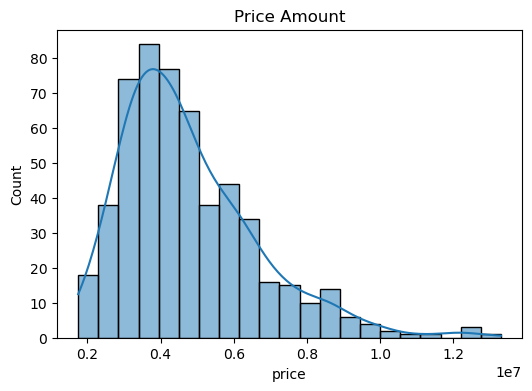

In [ ]:
# Plotting for the distribution of price amount
plt.figure(figsize=(6, 4))
sns.histplot(df["price"], kde=True)
plt.title("Price Amount")

Text(0.5, 1.0, 'Area Vs Price')

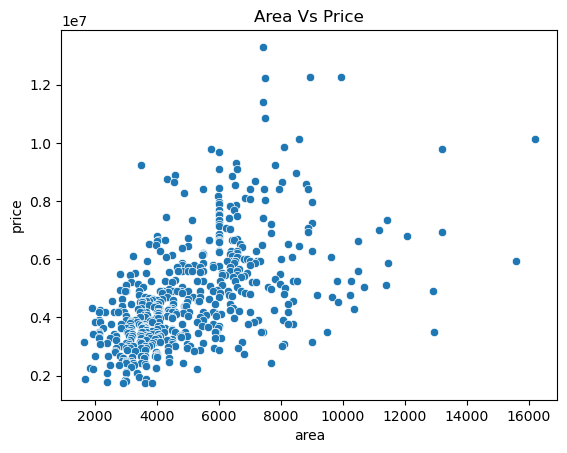

In [ ]:
# Checking Price with a main feature to look at their relation
sns.scatterplot(x="area", y="price", data=df)
plt.title("Area Vs Price")

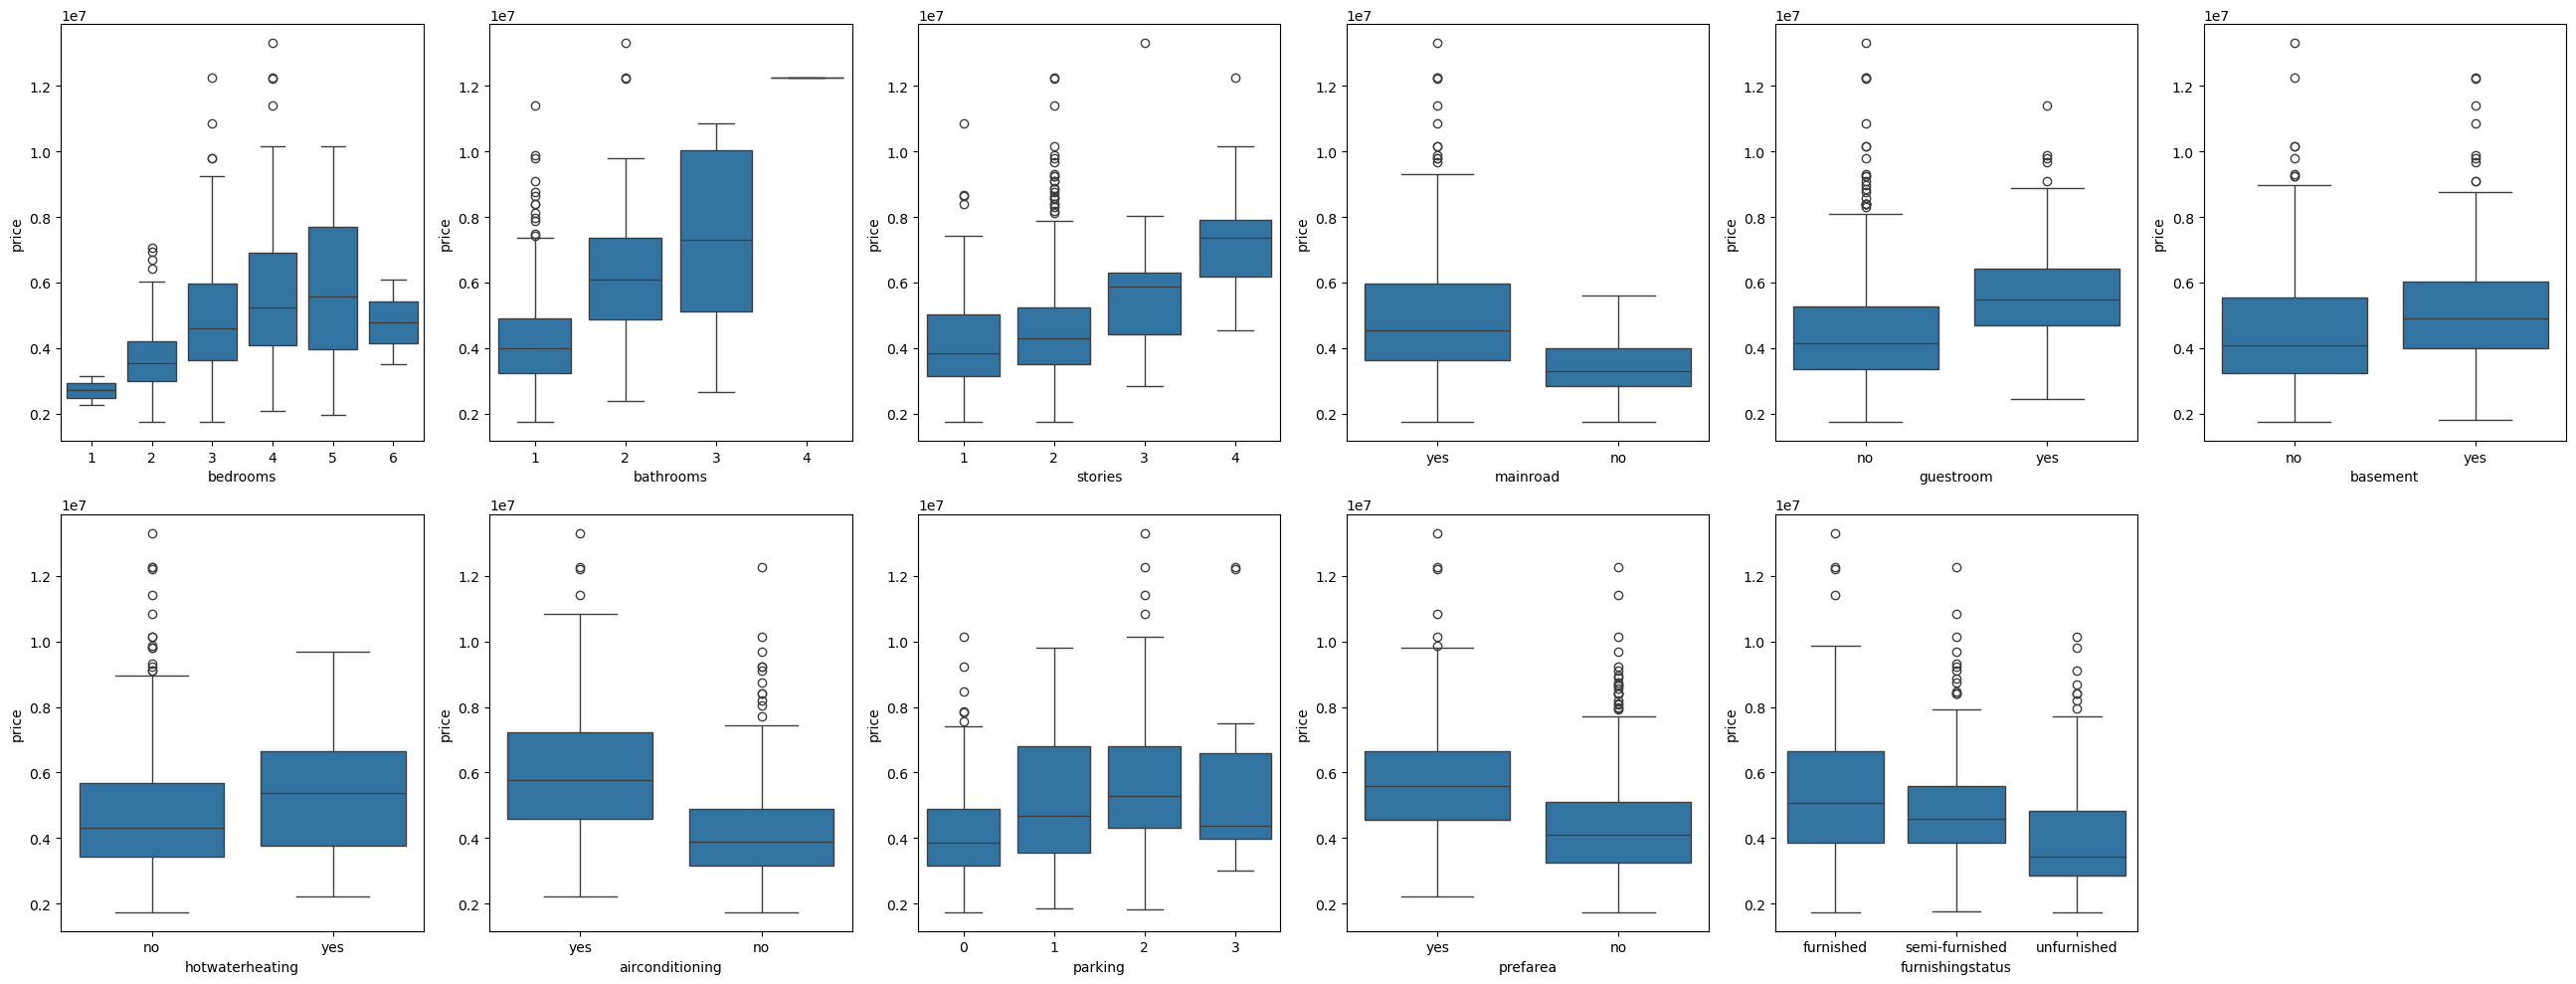

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(26, 10))
sns.boxplot(x="bedrooms", y="price", data=df, ax=axes[0, 0])
sns.boxplot(x="bathrooms", y="price", data=df, ax=axes[0, 1])
sns.boxplot(x="stories", y="price", data=df, ax=axes[0, 2])
sns.boxplot(x="mainroad", y="price", data=df, ax=axes[0, 3])
sns.boxplot(x="guestroom", y="price", data=df, ax=axes[0, 4])
sns.boxplot(x="basement", y="price", data=df, ax=axes[0, 5])
sns.boxplot(x="hotwaterheating", y="price", data=df, ax=axes[1, 0])
sns.boxplot(x="airconditioning", y="price", data=df, ax=axes[1, 1])
sns.boxplot(x="parking", y="price", data=df, ax=axes[1, 2])
sns.boxplot(x="prefarea", y="price", data=df, ax=axes[1, 3])
sns.boxplot(x="furnishingstatus", y="price", data=df, ax=axes[1, 4])
fig.delaxes(axes[1, 5])
plt.tight_layout()
plt.show()

In [ ]:
# Convert object datatypes to category datatypes
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Make category data to binary data no=0 and yes=1, and seperate furnishingstatus column to different features
df["mainroad"] = df["mainroad"].cat.codes
df["guestroom"] = df["guestroom"].cat.codes
df["basement"] = df["basement"].cat.codes
df["hotwaterheating"] = df["hotwaterheating"].cat.codes
df["airconditioning"] = df["airconditioning"].cat.codes
df["prefarea"] = df["prefarea"].cat.codes

df = pd.get_dummies(df, columns=["furnishingstatus"], prefix="Furnishing")

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,Furnishing_furnished,Furnishing_semi-furnished,Furnishing_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [ ]:
# make and add price square meter to the dataset
df["price_Square_meter"] = df["price"]/df["area"]
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,Furnishing_furnished,Furnishing_semi-furnished,Furnishing_unfurnished,price_Square_meter
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False,1792.452830
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False,1367.187500
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False,1229.919679
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False,1628.666667
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False,1537.735849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,False,True,606.666667
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,False,True,False,736.312500
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,False,True,483.425414
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,True,False,False,601.374570


In [ ]:
# checking the correlation with the target(price)
df.corr()["price"].sort_values(ascending=False)

price                        1.000000
area                         0.535997
bathrooms                    0.517545
airconditioning              0.452954
stories                      0.420712
price_Square_meter           0.392921
parking                      0.384394
bedrooms                     0.366494
prefarea                     0.329777
mainroad                     0.296898
guestroom                    0.255517
Furnishing_furnished         0.229350
basement                     0.187057
hotwaterheating              0.093073
Furnishing_semi-furnished    0.063656
Furnishing_unfurnished      -0.280587
Name: price, dtype: float64

<Axes: >

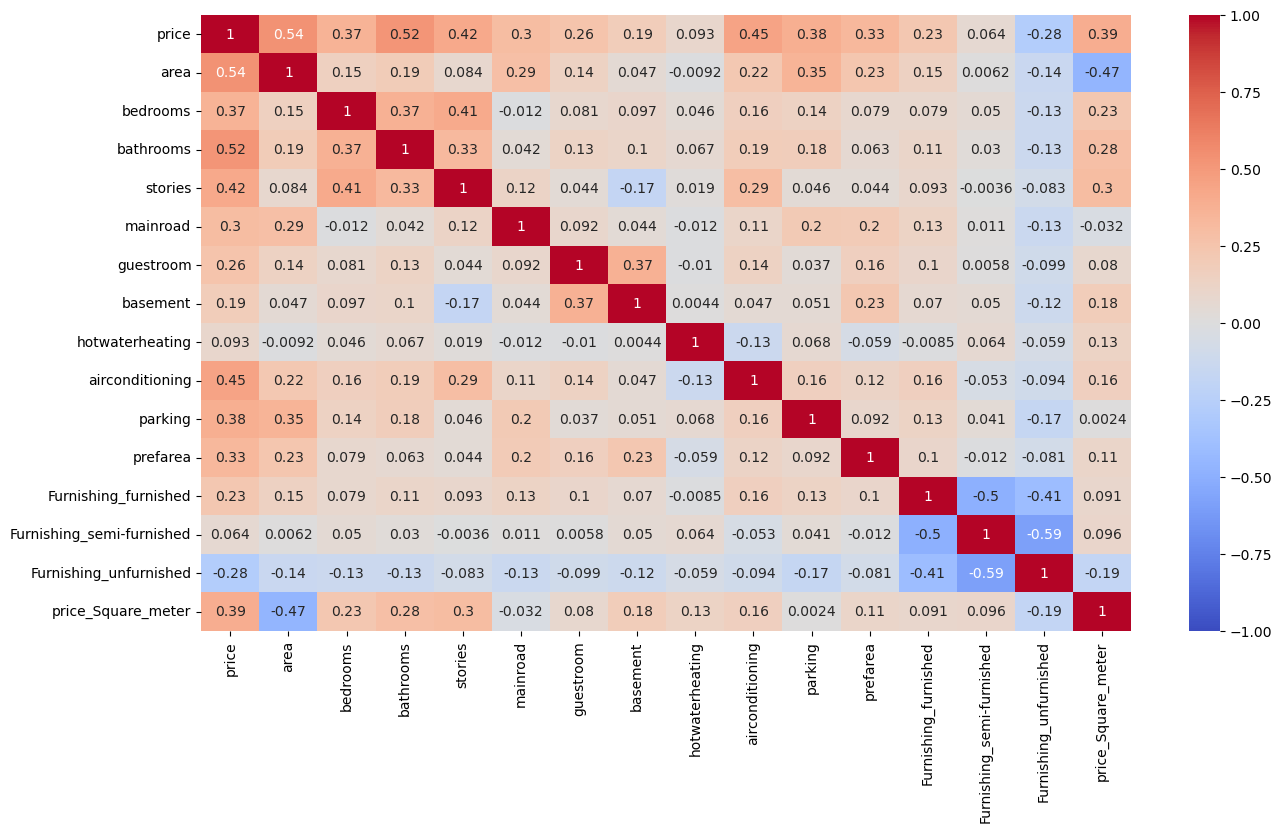

In [ ]:
# Checking the dataset correlation with heatmap plotting
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)

In [ ]:
# Standardize the datasets to improve evaluation performance
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
numerical_features = ["price", "area", "bedrooms", "bathrooms", "stories", "parking", "price_Square_meter"]

df[numerical_features] = scalar.fit_transform(df[numerical_features])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,Furnishing_furnished,Furnishing_semi-furnished,Furnishing_unfurnished,price_Square_meter
0,4.566365,1.046726,1.403419,1.421812,1.378217,1,0,0,0,1,1.517692,1,True,False,False,2.308152
1,4.004484,1.757010,1.403419,5.405809,2.532024,1,0,0,0,1,2.679409,0,True,False,False,1.079838
2,4.004484,2.218232,0.047278,1.421812,0.224410,1,0,1,0,0,1.517692,1,False,True,False,0.683361
3,3.985755,1.083624,1.403419,1.421812,0.224410,1,0,1,0,1,2.679409,1,True,False,False,1.835081
4,3.554979,1.046726,1.403419,-0.570187,0.224410,1,1,1,0,1,1.517692,0,True,False,False,1.572441


In [ ]:
# Choosing features for X and y
X = df.drop(columns="price")
y = df["price"]

In [ ]:
# Selected good features for the best performance 
selected_features = ["area", "bathrooms", "airconditioning", "stories", "price_Square_meter", "parking", "bedrooms", "prefarea", "mainroad", "guestroom", "Furnishing_furnished", "basement", "hotwaterheating", "Furnishing_semi-furnished"]
X_selected = X[selected_features]
X_selected.head()

,area,bathrooms,airconditioning,stories,price_Square_meter,parking,bedrooms,prefarea,mainroad,guestroom,Furnishing_furnished,basement,hotwaterheating,Furnishing_semi-furnished
0,1.046726,1.421812,1,1.378217,2.308152,1.517692,1.403419,1,1,0,True,0,0,False
1,1.757010,5.405809,1,2.532024,1.079838,2.679409,1.403419,0,1,0,True,0,0,False
2,2.218232,1.421812,0,0.224410,0.683361,1.517692,0.047278,1,1,0,False,1,0,True
3,1.083624,1.421812,1,0.224410,1.835081,2.679409,1.403419,1,1,0,True,1,0,False
4,1.046726,-0.570187,1,0.224410,1.572441,1.517692,1.403419,0,1,1,True,1,0,False


In [ ]:
# Split dataset for tarin and test 
from sklearn.model_selection import train_test_split

X = X_selected.astype(np.float64)
y = df["price"].astype(np.float64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Import LinearRegression model to fit the training dataset
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Checking the coeficient of features
lr_model.coef_

array([ 0.6766806 ,  0.14138411,  0.25879456,  0.06960501,  0.60539987,
        0.05760189, -0.00109592,  0.07592693,  0.15054451,  0.15143638,
        0.0088384 ,  0.00682824,  0.0961375 , -0.00793648])

In [ ]:
# Checking the intercept
lr_model.intercept_

np.float64(-0.27059004700405526)

In [ ]:
# Create an evaluation function for checking each model
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_train, y_train, X_test, y_test):

    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    print("Training set results: ")
    print(f"MSE Train : {mse_train}")
    print(f"R-Squared : {r2_train}")
    print(f"RMSE Train : {rmse_train}")

    print("\nTest set results: ")
    print(f"MSE Test : {mse_test}")
    print(f"R-Squared : {r2_test}")
    print(f"RMSE Test : {rmse_test}")
    return mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test

In [ ]:
# Evaluate LinearRegression model
evaluate_model(lr_model, X_train, y_train, X_test, y_test)

Training set results: 
MSE Train : 0.13649500019852961
R-Squared : 0.8454113050425558
RMSE Train : 0.369452297595413

Test set results: 
MSE Test : 0.16815465939453828
R-Squared : 0.8838245265717735
RMSE Test : 0.4100666523804859


(0.13649500019852961,
 np.float64(0.369452297595413),
 0.8454113050425558,
 0.16815465939453828,
 np.float64(0.4100666523804859),
 0.8838245265717735)

Text(0, 0.5, 'Predicted Price')

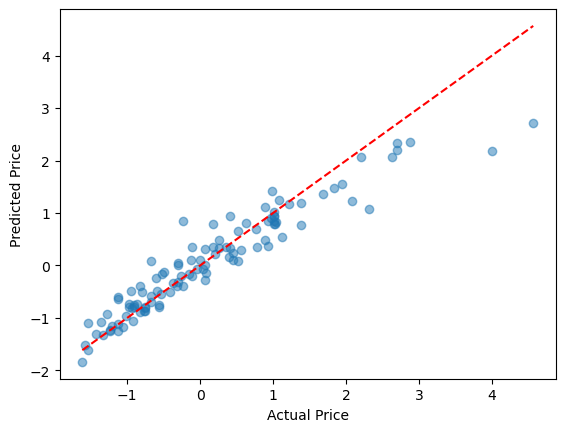

In [ ]:
# plotting actual test with predict test
y_test_pred = lr_model.predict(X_test)

plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

Text(0, 0.5, 'Residuals')

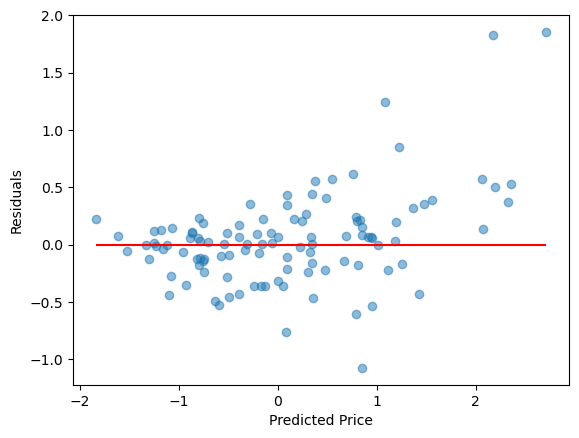

In [ ]:
# Plotting residuals for outliers
residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), colors='r')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

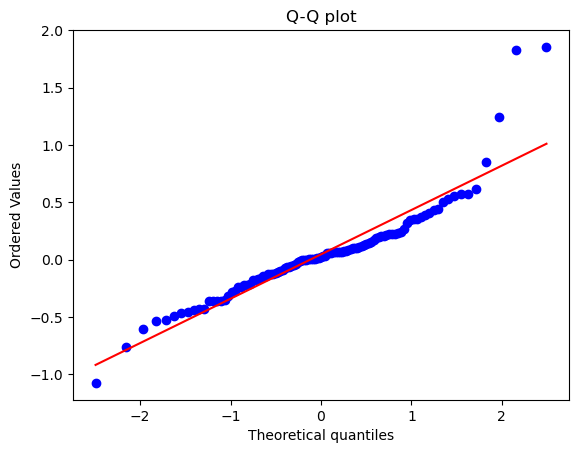

In [ ]:
# Plotting a Q–Q plot for a normal distribution
import scipy.stats as stats

fig, ax = plt.subplots()
stats.probplot(y_test - y_test_pred, plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

In [ ]:
# checking Ridge model for evaluation with alpha=0.1 hyperparameter
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

ridge_model = Ridge(alpha=0.1)

ridge_model.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [30]:
print("Ridge model Results: ")
evaluate_model(ridge_model, X_train, y_train, X_test, y_test)

Ridge model Results: 
Training set results: 
MSE Train : 0.13649516003361573
R-Squared : 0.8454111240198272
RMSE Train : 0.3694525139089132

Test set results: 
MSE Test : 0.1682911931790641
R-Squared : 0.8837301974754919
RMSE Test : 0.41023309615274106


(0.13649516003361573,
 np.float64(0.3694525139089132),
 0.8454111240198272,
 0.1682911931790641,
 np.float64(0.41023309615274106),
 0.8837301974754919)

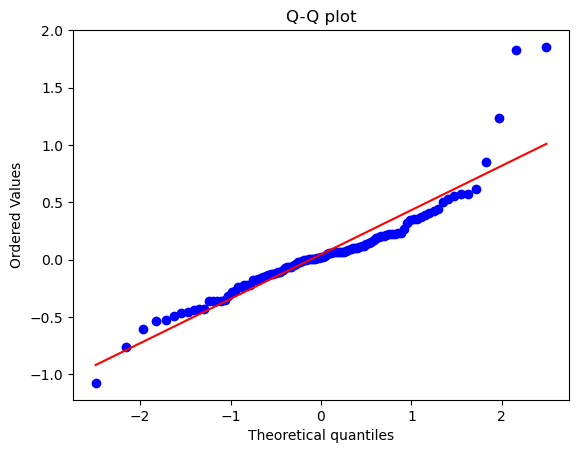

In [ ]:
# Plotting a Q–Q plot for a normal distribution for Ridge model
y_test_pred = ridge_model.predict(X_test)

fig, ax = plt.subplots()
stats.probplot(y_test - y_test_pred, plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

In [ ]:
# checking Lasso model for evaluation with alpha=0.1 hyperparameter
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [33]:
print("Lasso model Results: ")
evaluate_model(lasso_model, X_train, y_train, X_test, y_test)

Lasso model Results: 
Training set results: 
MSE Train : 0.19942263624253123
R-Squared : 0.7741420195841128
RMSE Train : 0.44656761665231753

Test set results: 
MSE Test : 0.31955221563969227
R-Squared : 0.7792262785304314
RMSE Test : 0.5652894971956336


(0.19942263624253123,
 np.float64(0.44656761665231753),
 0.7741420195841128,
 0.31955221563969227,
 np.float64(0.5652894971956336),
 0.7792262785304314)

In [34]:
lasso_model.coef_

array([0.5964649 , 0.12513988, 0.        , 0.06024169, 0.4920993 ,
       0.02693966, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

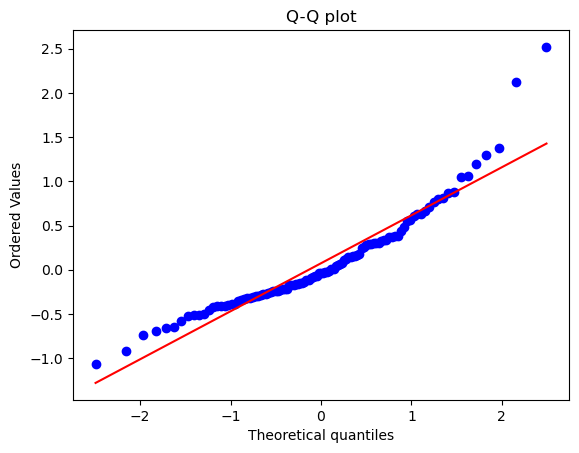

In [ ]:
# Plotting a Q–Q plot for a normal distribution for Lasso model
y_test_pred = lasso_model.predict(X_test)

fig, ax = plt.subplots()
stats.probplot(y_test - y_test_pred, plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()